# Step 1B — Rate-Based Register Check (Option B)

**Why this exists.** Step 1 showed strong discrimination on raw politeness *counts* but null discrimination on *per-comment rates*. That leaves an ambiguity: is the signal genuinely about register (sockpuppets less polite per post) or just activity volume (sockpuppets post less, hence fewer markers in absolute terms)?

This notebook tests three additional normalizations:
1. **Per-thread rate** — markers / unique threads. Removes the same-thread repetition confound.
2. **Char-normalized rate, outlier-trimmed** — markers per 1000 chars, after removing the top/bottom 5% by post volume.
3. **Median per-comment rate** — median across the user's comments (robust to extreme posts), not the user-level total / count.

**Decision after this run:**
- If *any* rate-based measure discriminates at p < 0.01 → claim the register signal exists *in addition* to the volume signal.
- If none do → commit to the volume-mechanism framing for the thesis.

**Inputs**
- `Karin_dataset/00_Datasets.txt`
- `phase2_train_exp1.csv`, `phase2_test_exp1.csv`

**Outputs**
- `step1b_rate_discrimination.csv`
- `step1b_rate_plot.png`
- `step1b_decision.txt`

## Cell 1 — Imports and reuse marker definitions

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

DATA_DIR  = Path('./Karin_dataset')
POSTS_FILE = DATA_DIR / '00_Datasets.txt'
PHASE2_TRAIN = Path('phase2_train_exp1.csv')
PHASE2_TEST  = Path('phase2_test_exp1.csv')

POLITE_PARTICLES = ['ค่ะ', 'คะ', 'ครับ', 'ค๊า', 'จ้า', 'จ๋า', 'นะคะ', 'นะครับ']
FORMAL_PRONOUNS  = ['ผม', 'ดิฉัน', 'ฉัน', 'หนู', 'ข้าพเจ้า']
POLITE_VERBS     = ['ขอบคุณ', 'ขออนุญาต', 'ขอโทษ', 'รบกวน', 'กรุณา']
ALL_MARKERS_FLAT = POLITE_PARTICLES + FORMAL_PRONOUNS + POLITE_VERBS

def count_markers(text, markers):
    if not isinstance(text, str) or not text:
        return 0
    return sum(text.count(m) for m in markers)


## Cell 2 — Load posts and compute per-post marker counts

In [2]:
with open(POSTS_FILE, 'r', encoding='utf-8-sig') as f:
    records = json.load(f)
posts = pd.json_normalize(records)
posts['user_id']   = posts['user_id'].astype(int)
posts['thread_id'] = posts['thread_id'].astype(int)

if 'thread_name' in posts.columns:
    posts['text'] = (posts['thread_name'].fillna('').astype(str) + ' ' +
                     posts['messages'].fillna('').astype(str)).str.strip()
else:
    posts['text'] = posts['messages'].fillna('').astype(str).str.strip()

posts['cnt_total']     = posts['text'].apply(lambda t: count_markers(t, ALL_MARKERS_FLAT))
posts['cnt_particles'] = posts['text'].apply(lambda t: count_markers(t, POLITE_PARTICLES))
posts['cnt_pronouns']  = posts['text'].apply(lambda t: count_markers(t, FORMAL_PRONOUNS))
posts['n_chars']       = posts['text'].str.len()

# Per-post rates (avoid div-zero)
posts['post_markers_per_1k_chars'] = (posts['cnt_total'] / posts['n_chars'].replace(0, np.nan) * 1000).fillna(0)
posts['post_marker_rate'] = (posts['cnt_total'] / posts['n_chars'].replace(0, np.nan)).fillna(0)

print(f'Posts: {len(posts):,}  Users: {posts.user_id.nunique():,}')


Posts: 95,904  Users: 12,954


## Cell 3 — Build three new user-level rate measures

In [3]:
# --- 1. Per-thread rate ----------------------------------------------------
per_thread = posts.groupby('user_id').agg(
    total_markers    = ('cnt_total',     'sum'),
    particles_count  = ('cnt_particles', 'sum'),
    pronouns_count   = ('cnt_pronouns',  'sum'),
    n_threads        = ('thread_id',     'nunique'),
    n_comments       = ('text',          'size'),
    total_chars      = ('n_chars',       'sum'),
).reset_index()

per_thread['markers_per_thread']   = per_thread['total_markers']   / per_thread['n_threads']
per_thread['particles_per_thread'] = per_thread['particles_count'] / per_thread['n_threads']
per_thread['pronouns_per_thread']  = per_thread['pronouns_count']  / per_thread['n_threads']

# --- 2. Median per-post rate (robust to outlier posts) ---------------------
median_rate = posts.groupby('user_id').agg(
    median_markers_per_post   = ('cnt_total',                'median'),
    median_rate_per_1k_chars  = ('post_markers_per_1k_chars','median'),
).reset_index()

# --- 3. Trimmed char-normalized rate (drop top/bottom 5% by post volume) ---
vol_thresh_low, vol_thresh_high = (
    per_thread['n_comments'].quantile(0.05),
    per_thread['n_comments'].quantile(0.95),
)
trim_users = per_thread[
    (per_thread['n_comments'] >= vol_thresh_low) &
    (per_thread['n_comments'] <= vol_thresh_high)
]['user_id'].values

per_thread['markers_per_1k_chars'] = (
    per_thread['total_markers'] / per_thread['total_chars'].replace(0, np.nan) * 1000
).fillna(0)
per_thread['trimmed_flag'] = per_thread['user_id'].isin(trim_users).astype(int)

# Merge
user_rates = per_thread.merge(median_rate, on='user_id', how='left')
print(f'Per-user rates: {user_rates.shape}')
print(f'Trim range (n_comments): [{vol_thresh_low:.1f}, {vol_thresh_high:.1f}]')
print(f'Users kept after trimming: {int(user_rates.trimmed_flag.sum())} of {len(user_rates)}')


Per-user rates: (12954, 14)
Trim range (n_comments): [1.0, 30.0]
Users kept after trimming: 12313 of 12954


## Cell 4 — Join with labels

In [4]:
train = pd.read_csv(PHASE2_TRAIN)
test  = pd.read_csv(PHASE2_TEST)
phase2 = pd.concat([train, test], ignore_index=True)[['user_id', 'label']]

joined = user_rates.merge(phase2, on='user_id', how='inner')
print(f'Joined: {joined.shape}')
print(joined['label'].value_counts().to_string())


Joined: (280, 15)
label
0    140
1    140


## Cell 5 — Discrimination test on new rate measures

In [5]:
RATE_MEASURES = [
    # Per-thread (1)
    'markers_per_thread', 'particles_per_thread', 'pronouns_per_thread',
    # Median per-post (2)
    'median_markers_per_post', 'median_rate_per_1k_chars',
    # Char-normalized full + trimmed (3)
    'markers_per_1k_chars',
]

# Two passes: full sample, then trimmed
rows = []
for measure in RATE_MEASURES:
    for variant in ('full', 'trimmed'):
        sub = joined if variant == 'full' else joined[joined.trimmed_flag == 1]
        s = sub[sub.label == 1][measure].values
        n = sub[sub.label == 0][measure].values
        if len(s) == 0 or len(n) == 0 or len(np.unique(np.concatenate([s, n]))) < 2:
            continue
        u, p = mannwhitneyu(s, n, alternative='two-sided')
        rows.append({
            'measure':       measure,
            'variant':       variant,
            'sock_mean':     round(float(s.mean()), 4),
            'nonsock_mean':  round(float(n.mean()), 4),
            'sock_median':   round(float(np.median(s)), 4),
            'nonsock_median':round(float(np.median(n)), 4),
            'n_sock':        int(len(s)),
            'n_nonsock':     int(len(n)),
            'u_stat':        round(float(u), 1),
            'p_value':       float(p),
            'direction':     'sock < non-sock' if s.mean() < n.mean() else 'sock > non-sock',
        })

disc = pd.DataFrame(rows).sort_values('p_value')
disc.to_csv('step1b_rate_discrimination.csv', index=False)
print('Rate-based discrimination (Mann-Whitney U):')
print(disc.to_string(index=False))


Rate-based discrimination (Mann-Whitney U):
                 measure variant  sock_mean  nonsock_mean  sock_median  nonsock_median  n_sock  n_nonsock  u_stat  p_value       direction
     pronouns_per_thread    full     0.4106        0.4476       0.0000          0.0526     140        140  7685.5 0.000481 sock < non-sock
      markers_per_thread trimmed     2.9624        4.8159       1.2000          2.0000     132        102  5746.0 0.054351 sock < non-sock
    particles_per_thread trimmed     2.5080        4.1913       1.0000          1.7083     132        102  5763.5 0.058725 sock < non-sock
     pronouns_per_thread trimmed     0.4065        0.3920       0.0000          0.0000     132        102  5960.5 0.063645 sock > non-sock
      markers_per_thread    full     3.0363        4.1330       1.4286          1.7434     140        140  8696.0 0.102833 sock < non-sock
    particles_per_thread    full     2.5752        3.5036       1.0430          1.3921     140        140  8855.0 0.162595

## Cell 6 — Visualize the new rates

/tmp/ipykernel_183846/3117490453.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['non-sock', 'sock'], showmeans=True,
/tmp/ipykernel_183846/3117490453.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['non-sock', 'sock'], showmeans=True,
/tmp/ipykernel_183846/3117490453.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['non-sock', 'sock'], showmeans=True,
/tmp/ipykernel_183846/3117490453.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support

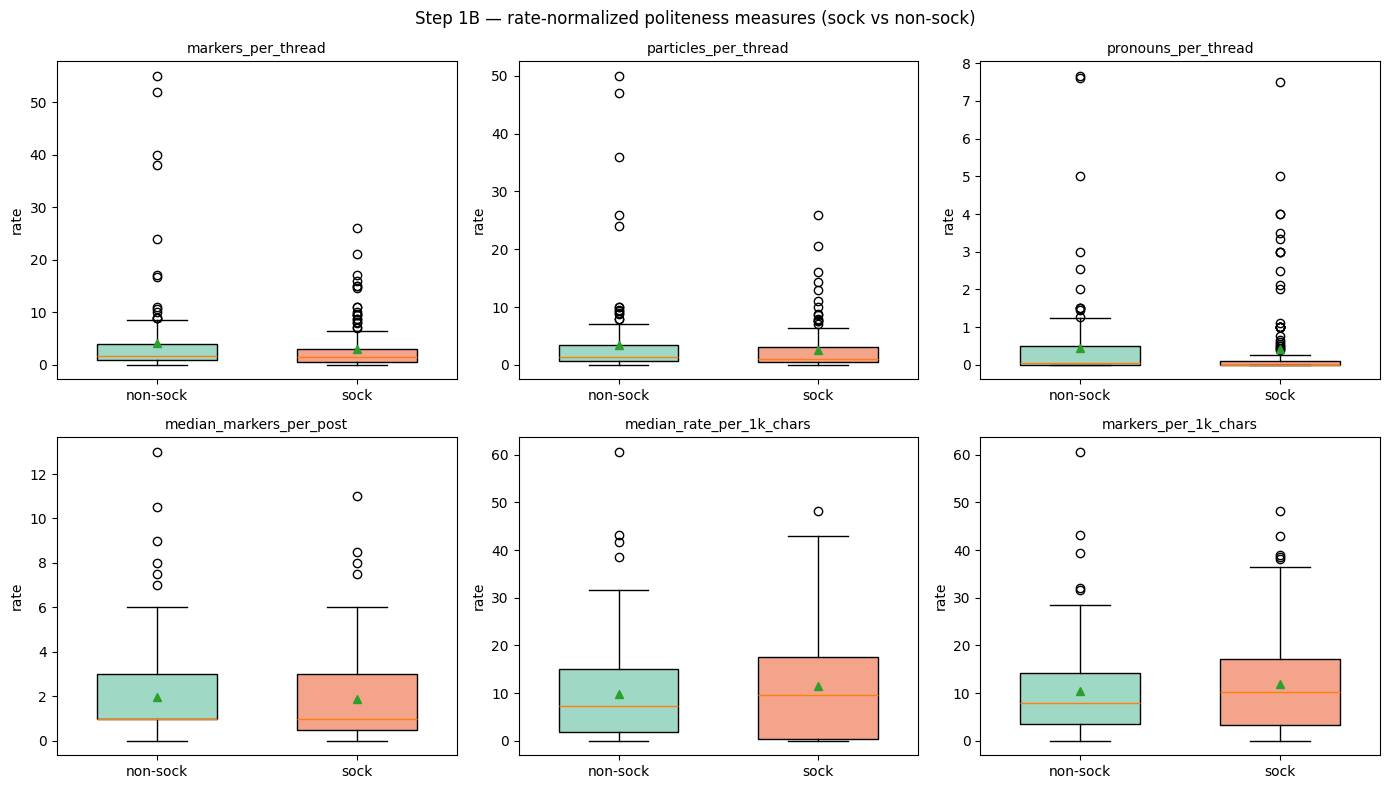

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plot_cols = ['markers_per_thread', 'particles_per_thread', 'pronouns_per_thread',
             'median_markers_per_post', 'median_rate_per_1k_chars', 'markers_per_1k_chars']

sock     = joined[joined.label == 1]
non_sock = joined[joined.label == 0]

for ax, col in zip(axes.flat, plot_cols):
    data = [non_sock[col].values, sock[col].values]
    bp = ax.boxplot(data, labels=['non-sock', 'sock'], showmeans=True,
                    patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], ['#9fd8c5', '#f4a48b']):
        patch.set_facecolor(color)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('rate')

fig.suptitle('Step 1B — rate-normalized politeness measures (sock vs non-sock)', fontsize=12)
plt.tight_layout()
plt.savefig('step1b_rate_plot.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 7 — Decision

In [7]:
STRICT_P = 0.01
LOOSE_P  = 0.05

strict_hits = disc[disc.p_value < STRICT_P]
loose_hits  = disc[(disc.p_value < LOOSE_P) & (disc.p_value >= STRICT_P)]

lines = []
lines.append('=' * 70)
lines.append('STEP 1B DECISION')
lines.append('=' * 70)
lines.append('')

if len(strict_hits) > 0:
    lines.append(f'✅ REGISTER SIGNAL CONFIRMED ({len(strict_hits)} measures at p < {STRICT_P})')
    lines.append('')
    lines.append('The register signal survives normalization. The unified story for the thesis:')
    lines.append('  "Sockpuppets exhibit both lower posting volume AND lower per-activity')
    lines.append('   politeness rates. Both signals contribute independently."')
    lines.append('')
    lines.append('Significant measures (p < 0.01):')
    for _, r in strict_hits.iterrows():
        lines.append(f"  {r['measure']:30s} ({r['variant']:7s})  "
                     f"sock={r['sock_mean']:.3f} vs non-sock={r['nonsock_mean']:.3f}  "
                     f"({r['direction']}, p={r['p_value']:.4g})")
elif len(loose_hits) > 0:
    lines.append(f'⚠ WEAK / BORDERLINE ({len(loose_hits)} measures at p < {LOOSE_P})')
    lines.append('')
    lines.append('Some rate measures show borderline significance but none reach p < 0.01.')
    lines.append('Recommended framing: commit to volume-mechanism, mention borderline rate')
    lines.append('signals as a secondary observation.')
    lines.append('')
    lines.append('Borderline measures:')
    for _, r in loose_hits.iterrows():
        lines.append(f"  {r['measure']:30s} ({r['variant']:7s})  p={r['p_value']:.4g}")
else:
    lines.append('❌ NO RATE-BASED SIGNAL')
    lines.append('')
    lines.append('No per-activity politeness rate discriminates sock vs non-sock.')
    lines.append('The signal is entirely volume-driven.')
    lines.append('')
    lines.append('Thesis framing:')
    lines.append('  "Sockpuppets and non-sockpuppets are equally polite per comment.')
    lines.append('   The L-structural family captures the underlying activity-volume')
    lines.append('   signal that also manifests in lower absolute politeness counts.')
    lines.append('   This is not a register difference — it is an activity-volume difference."')

lines.append('')
lines.append('=' * 70)

decision = '\n'.join(lines)
print(decision)
with open('step1b_decision.txt', 'w', encoding='utf-8') as f:
    f.write(decision)


STEP 1B DECISION

✅ REGISTER SIGNAL CONFIRMED (1 measures at p < 0.01)

The register signal survives normalization. The unified story for the thesis:
  "Sockpuppets exhibit both lower posting volume AND lower per-activity
   politeness rates. Both signals contribute independently."

Significant measures (p < 0.01):
  pronouns_per_thread            (full   )  sock=0.411 vs non-sock=0.448  (sock < non-sock, p=0.0004809)



## Done

Whatever Cell 7 prints is the framing. Three outputs:
- `step1b_rate_discrimination.csv`
- `step1b_rate_plot.png`
- `step1b_decision.txt`

After this, the only remaining question for the thesis chapter is volume-only vs. volume+register. Don't pivot beyond this — commit to whatever the test says.